# Cost Fuction
* This explains how to: 
    * calculate distance between noise and samples 
    * estimate the best transform of samples to match noise 


In [9]:
import torch 
import matplotlib.pyplot as plt
from complex_moments_2d import CostConfig, CostFunction
from utils import plot_points_2d, sample_points, rotate_points_2d

config = CostConfig(
    max_frequency=4,# Number of frequencies to use for the moments
    moment_module="FlusserMoments", # Which moment module to use
    invariant_module="FlexibleInvariants", # Which invariant module to use
    alignment_module="KabschAlignment", # Which alignment module to use
    centered_samples=True, # Expecting centered noise and data samples
    norm_volume=True, # Normalize the moments by the volume of the point cloud
)

# Init layer that calculate distances and alignments between two point clouds
cost_fn = CostFunction(config)
cost_fn

CostFunction(
  (moments): FlusserMoments()
  (invariants): FlexibleInvariants()
  (alignment): KabschAlignment()
)

/Users/karella/Projects/flows/kt_flows/utils.py:49: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pts[..., 0], pts[..., 1], color=color, marker=marker)


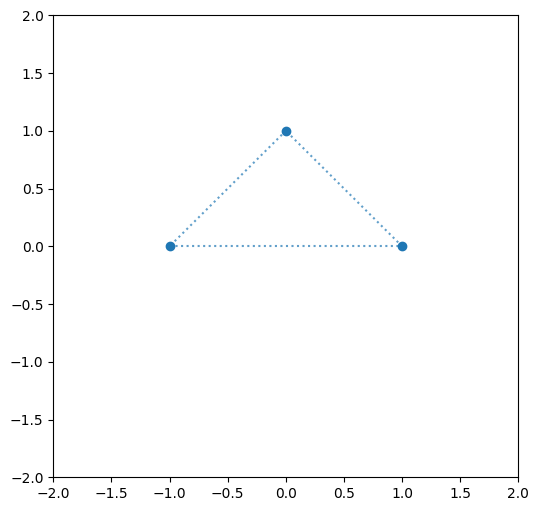

In [10]:
# Random sample for invariance check 
point = torch.tensor([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0]])[None,...] # [N, D]
fig, ax = plt.subplots(figsize=(6, 6))
plot_points_2d(point, title="Example point", ax=ax)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
# Test invariance to rotation, it will raise an error if the invariants are not working correctly
cost_fn.test_points(point, angle=torch.pi / 4)

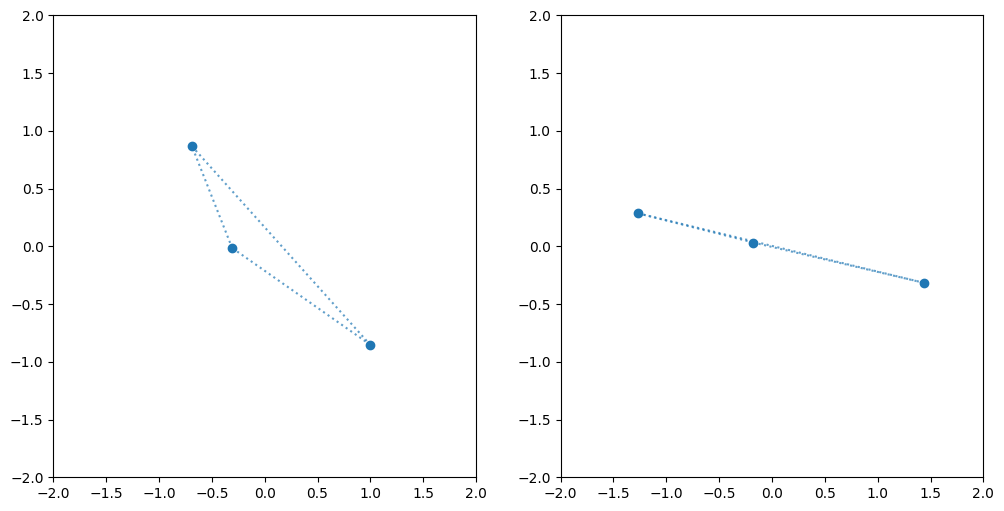

In [12]:
# Generate random points from Gaussian and centered at the origin
batch_size = 8
n_points = 3
dimension = 2

samples = sample_points(batch_size,
                       n_points,
                       dimension,
                       centered=True)
noise = sample_points(batch_size,
                      n_points,
                      dimension,
                      centered=True)
_, axs = plt.subplots(1, 2, figsize=(12, 6))
plot_points_2d(samples[0:1], title="Random sample of points", ax=axs[0], color_map="tab10")
plot_points_2d(noise[0:1], title="Random sample of noise", ax=axs[1], color_map="tab10")
# set limits 
for ax in axs:
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
# Check if the means are close to zero
assert torch.allclose(samples.mean(dim=-2), torch.zeros(dimension), atol=1e-6), "Samples are not centered"
assert torch.allclose(noise.mean(dim=-2), torch.zeros(dimension), atol=1e-6), "Noise is not centered"

/Users/karella/Projects/flows/kt_flows/utils.py:49: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pts[..., 0], pts[..., 1], color=color, marker=marker)


<Axes: >

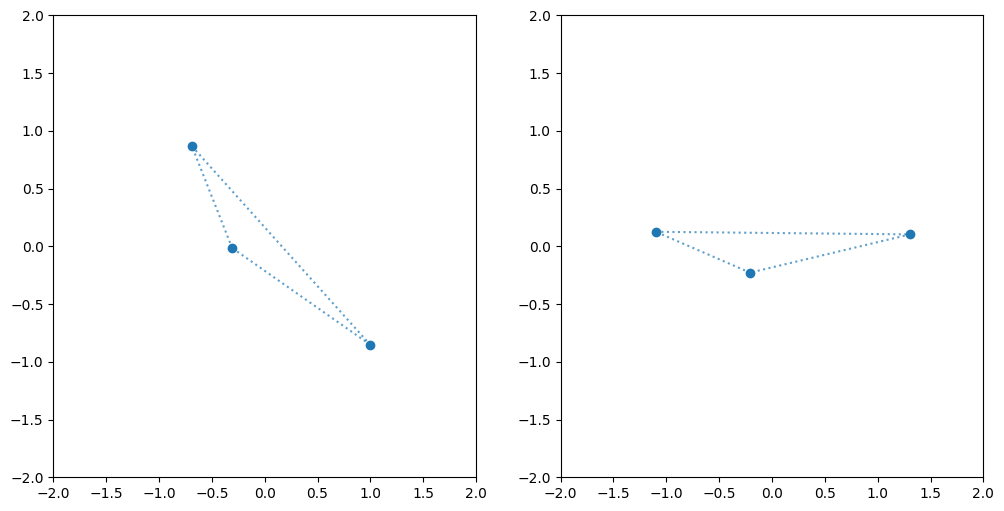

In [15]:
# Add one random rotation and permutation of first sample for testing
test_idx = 4
test_angle = torch.pi / 4
same_sample_point = samples[0]
same_noise_point = rotate_points_2d(samples[0].clone(), test_angle) # [N, D]

noise[test_idx] = same_noise_point
# Plot the original and rotated version
_, axs = plt.subplots(1, 2, figsize=(12, 6))
for ax in axs:
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
plot_points_2d(samples[0:1], title="Original points in Samples", ax=axs[0])
plot_points_2d(noise[test_idx:test_idx+1], title="Rotated points in Noise", ax=axs[1])

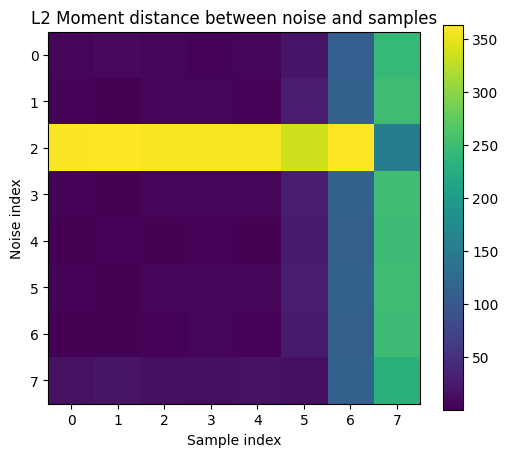

In [16]:
# Run the cost function and alignment
L2_dist, paired_samples, g = cost_fn(noise=noise,
                                      samples=samples)

# Plot L2 as heat matrix
plt.figure(figsize=(6, 5))
plt.imshow(L2_dist.cpu(), cmap="viridis")
plt.colorbar()
plt.title("L2 Moment distance between noise and samples")
plt.xlabel("Sample index")
plt.ylabel("Noise index")
plt.show()

# Test if the rotated sample is correctly aligned with the original sample
assert torch.all(noise[test_idx] == same_noise_point), "The noise point should be the same as the rotated sample point"
assert torch.all(paired_samples[test_idx] == same_sample_point), "The paired sample point should be the same as the original sample point"

/Users/karella/Projects/flows/kt_flows/utils.py:49: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pts[..., 0], pts[..., 1], color=color, marker=marker)


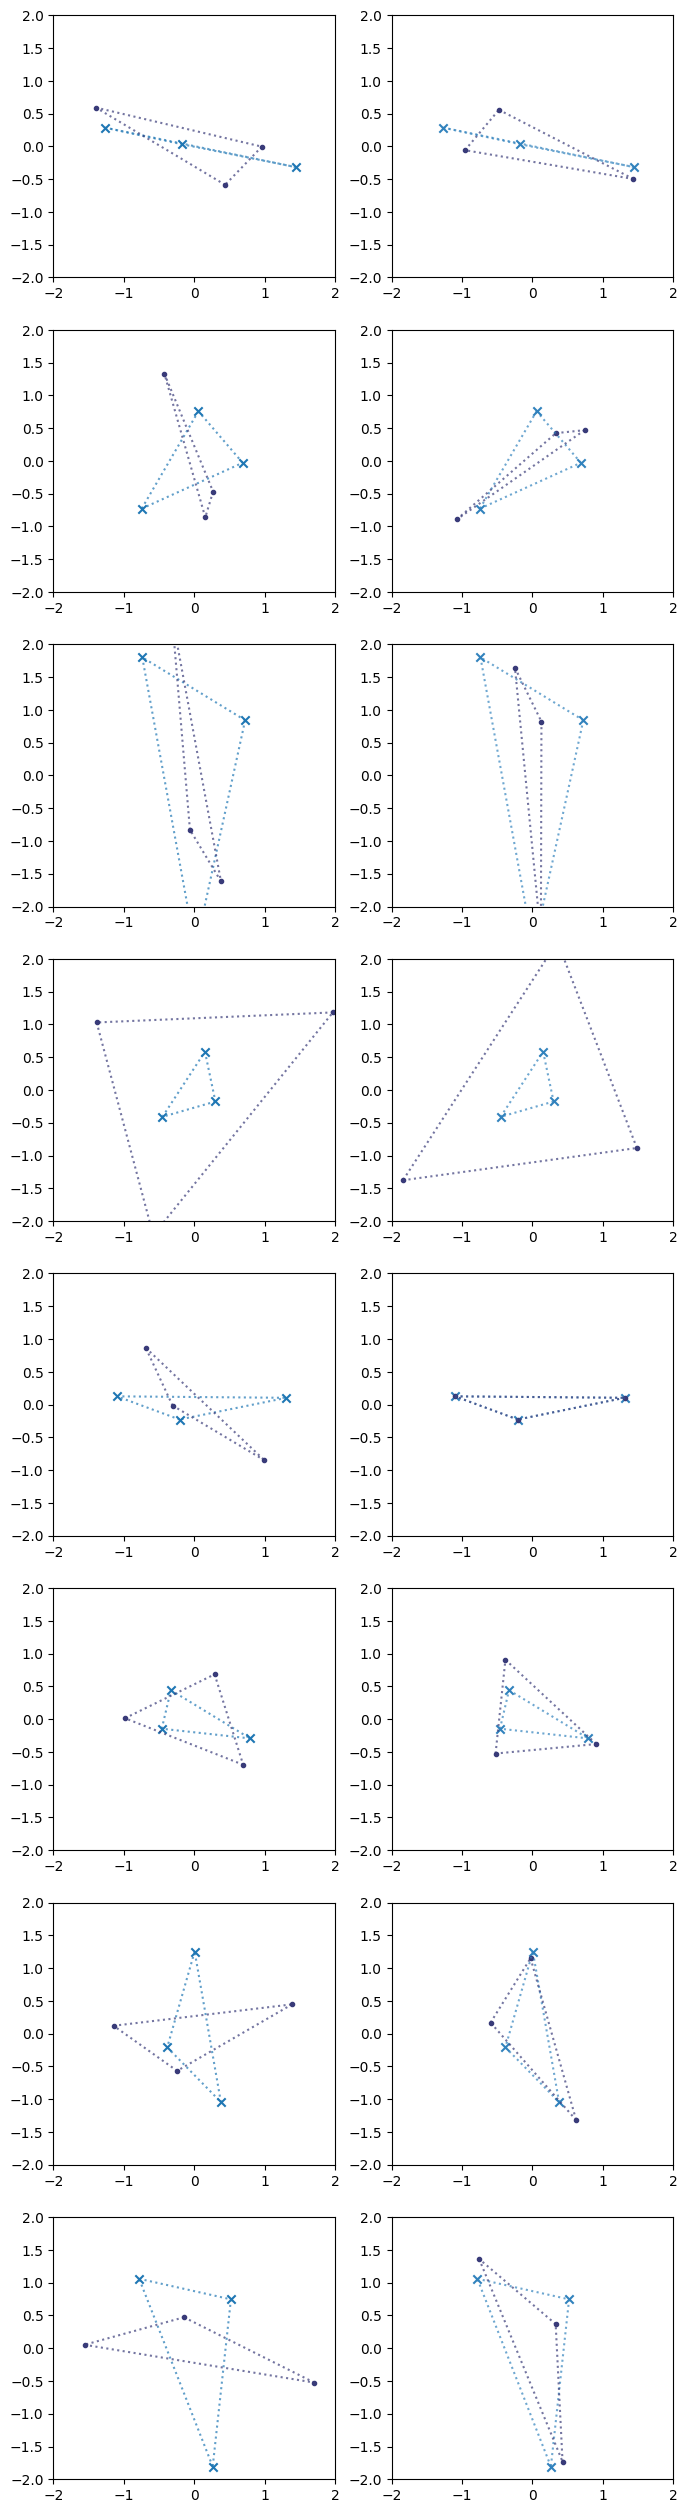

In [25]:
# Plot the pairs
Rs, Ps, ts = g
_, axs = plt.subplots(batch_size, 2, figsize=(8, 4 * batch_size))
# set limits
for ax in axs.flatten():
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
for i in range(batch_size):
    plot_points_2d(noise[i:i+1], title=f"Pair {i}", ax=axs[i, 0], color_map="tab10", marker='x')
    plot_points_2d(paired_samples[i:i+1], title=f"Matched sample {i}", ax=axs[i, 0], color_map="tab20b", marker='.')
    plot_points_2d(noise[i:i+1], title=f"Alignment {i}", ax=axs[i, 1], color_map="tab20c", marker='x')
    R, P, t = Rs[i], Ps[i], ts[i]
    assert torch.all(t < 1e-6), "Translation should be close to zero"
    # Note: Permutation does not change the point cloud, so we can ignore it for visualization
    angle = torch.atan2(R[1, 0], R[0, 0])
    aligned_sample = rotate_points_2d(paired_samples[i], angle)
    plot_points_2d(aligned_sample[None, ...], title=f"Alignment {i}", ax=axs[i, 1], marker='.', color_map="tab20b")
